# Лабораторная работа№5: Парсинг и обработка веб-логов с помощью Apache Spark

Дисциплина: Технологии и инструментарий анализа больших данных
Продолжительность: 4 академических часа
Среда выполнения: Google Colab

# Цель работы
Получить практические навыки обработки неструктурированных текстовых данных (веб-логов) с помощью Apache Spark, включая парсинг, трансформацию, агрегацию и анализ данных с использованием Spark SQL и DataFrame API.

# Задачи работы
1.	Настроить среду выполнения в Google Colab для работы с PySpark
2.	Сгенерировать синтетические веб-логи в формате Common Log Format (CLF)
3.	Выполнить парсинг логов с помощью регулярных выражений
4.	Преобразовать данные в DataFrame и выполнить аналитические запросы
5.	Провести временной анализ активности веб-сервера
6.	Сохранить результаты анализа и визуализировать ключевые метрики

# Теоретическая часть

Apache Spark — это мощный движок для обработки больших данных, который выполняет вычисления в памяти (in-memory), что обеспечивает высокую производительность. Ключевые особенности:
1) In-memory вычисления: Промежуточные данные хранятся в ОЗУ
2) Ленивые вычисления: Трансформации выполняются только при вызове действий
3) Единый фреймворк: Трансформации выполняются только при вызове действий
4) Масштабируемость: Масштабируемость	Работает на одном узле или в кластере из тысяч узлов

Основные абстракции Spark
1) RDD.
Описание:Низкоуровневый API, распределенная коллекция объектов.
Применение:Сложные преобразования, работа с неструктурированными данными
2)DataFrame
Описание:Табличная структура со схемой данных.
Применение:Структурированные данные, SQL-запросы, оптимизированные вычисления

Формат веб-логов Common Log Format (CLF)

Пример строки лога:
text
192.168.1.42 - - [15/Jan/2024:14:32:17 +0300] "GET /products/ HTTP/1.1" 200 15432

Структура полей:

1) host: IP-адрес или имя хоста клиента
2) timestamp:	Время запроса в формате [DD/MMM/YYYY:HH:MM:SS +TTTT]
3) method:	HTTP-метод (GET, POST, HEAD и др.)
4) endpoint:	Запрашиваемый URL
5) protocol:	Версия протокола (HTTP/1.1)
6) status:	Код ответа сервера (200, 404, 500 и др.)
7) bytes:	Размер ответа в байтах

# Ход выполнения работы

Часть 0. Настройка окружения в Google Colab

Выполните следующие ячейки для установки и настройки Spark.


In [4]:
# ============================================================
# Ячейка 0.1: Установка Java (требуется для Spark)
# ============================================================
!apt-get update -qq
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
print("✅ Java установлена")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
✅ Java установлена


In [5]:
# ============================================================
# Ячейка 0.2: Установка PySpark
# ============================================================
!pip install -q pyspark
print("✅ PySpark установлен")

✅ PySpark установлен


In [6]:
# ============================================================
# Ячейка 0.3: Установка PySpark
# ============================================================
!pip install -q pyspark

# ============================================================
# Настройка окружения
# ============================================================
import os

# В Colab Java уже установлена здесь:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

# Проверка
!java -version

# ============================================================
# Создание SparkSession
# ============================================================
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("WebLogsAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()

print(f"✅ Spark {spark.version} успешно запущен!")
print(f"🌐 Spark UI: {spark.sparkContext.uiWebUrl}")

openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
✅ Spark 4.0.2 успешно запущен!
🌐 Spark UI: http://eb2d833c136e:4040


In [7]:
# ============================================================
# Ячейка 0.4: Монтирование Google Drive (опционально)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive смонтирован. Результаты можно сохранять в /content/drive/MyDrive/")

Mounted at /content/drive
✅ Google Drive смонтирован. Результаты можно сохранять в /content/drive/MyDrive/


# Часть 1. Генерация тестовых данных

В этой части мы создадим синтетические веб-логи, имитирующие реальный трафик веб-сервера.

In [8]:
# # ============================================================
# # Ячейка 1.1: Генерация реалистичных веб-логов
# # ============================================================
# import random
# import datetime
# from collections import Counter

# def generate_apache_logs(num_lines=50000, output_file="apache_logs.txt"):
#     """
#     Генерирует реалистичные логи в формате Apache Common Log Format (CLF)

#     Параметры:
#         num_lines: количество генерируемых строк
#         output_file: имя выходного файла

#     Возвращает:
#         имя созданного файла
#     """

#     # ----- 1. Генерация пула IP-адресов -----
#     ip_pool = []

#     # Локальные IP (внутренняя сеть)
#     for i in range(1, 50):
#         ip_pool.append(f"192.168.1.{i}")
#     for i in range(1, 30):
#         ip_pool.append(f"10.0.0.{i}")

#     # Публичные IP (реальные пользователи)
#     public_ips = [
#         "85.140.0.1", "93.180.0.1", "176.9.0.1", "87.250.0.1",
#         "185.130.0.1", "31.13.0.1", "157.55.0.1", "40.77.0.1"
#     ]
#     ip_pool.extend(public_ips)

#     # IP ботов и краулеров
#     bot_ips = [
#         "66.249.66.1",   # Googlebot
#         "66.249.66.2",   # Googlebot
#         "157.55.39.250", # Bingbot
#         "52.70.240.171", # Amazonbot
#         "69.171.224.0",  # Facebook
#         "40.77.167.0"    # Bing
#     ]
#     ip_pool.extend(bot_ips)

#     # ----- 2. HTTP-методы с весами -----
#     methods = ['GET', 'POST', 'HEAD', 'PUT', 'DELETE']
#     method_weights = [0.85, 0.10, 0.03, 0.01, 0.01]  # GET — 85% запросов

#     # ----- 3. Реалистичные URL (эндпоинты) -----
#     urls = [
#         # Статические страницы
#         '/', '/index.html', '/about.html', '/contact.html', '/faq.html',
#         # Продукты
#         '/products/', '/products/1', '/products/2', '/products/3', '/products/4',
#         '/products/5', '/products/category/electronics', '/products/category/books',
#         # API эндпоинты
#         '/api/v1/users', '/api/v1/orders', '/api/v1/products', '/api/v1/auth',
#         '/api/v2/users', '/api/v2/orders',
#         # Статические ресурсы
#         '/css/main.css', '/css/theme.css', '/js/app.js', '/js/vendor.js',
#         '/images/logo.png', '/images/banner.jpg', '/fonts/roboto.woff2',
#         # Блог
#         '/blog/', '/blog/post/1', '/blog/post/2', '/blog/post/3',
#         '/blog/category/news', '/blog/category/tutorials',
#         # Админка (часто атакуемая)
#         '/admin/', '/admin/login', '/admin/dashboard', '/wp-admin/', '/wp-login.php',
#         # Поиск
#         '/search', '/search?q=spark', '/search?q=python', '/search?q=data'
#     ]

#     # ----- 4. HTTP-статусы с весами (реалистичное распределение) -----
#     statuses = (
#         [200] * 820 +     # 82% - успешные запросы
#         [301] * 30 +      # 3% - редиректы
#         [304] * 30 +      # 3% - не изменено
#         [400] * 15 +      # 1.5% - ошибка клиента
#         [403] * 15 +      # 1.5% - доступ запрещен
#         [404] * 60 +      # 6% - страница не найдена
#         [500] * 20 +      # 2% - внутренняя ошибка сервера
#         [503] * 10        # 1% - сервис недоступен
#     )


#     # ----- 5. Функция определения размера ответа -----
#     def get_content_size(status):
#         if status in [301, 302, 304]:
#             return random.choice([0, 100, 200, 500])
#         elif status in [400, 403, 404]:
#             return random.choice([200, 500, 1000, 2000, 5000])
#         elif status >= 500:
#             return random.choice([500, 1000, 2000, 5000])
#         else:
#             # Успешные ответы: от 500 байт до 5 МБ
#             return random.choice([500, 1000, 5000, 10000, 50000,
#                                   100000, 500000, 1000000, 5000000])

#     # ----- 6. Начальная дата (январь 2024) -----
#     start_date = datetime.datetime(2024, 1, 1, 0, 0, 0)

#     # ----- 7. Генерация логов -----
#     logs = []
#     for _ in range(num_lines):
#         # Случайная дата в течение января
#         days_offset = random.randint(0, 30)
#         seconds_offset = random.randint(0, 86399)
#         timestamp = start_date + datetime.timedelta(days=days_offset, seconds=seconds_offset)
#         timestamp_str = timestamp.strftime("%d/%b/%Y:%H:%M:%S %z")

#         ip = random.choice(ip_pool)
#         method = random.choices(methods, weights=method_weights)[0]
#         url = random.choice(urls)
#         status = random.choice(statuses)
#         size = get_content_size(status)

#         # Формирование строки лога в формате CLF
#         log_line = f'{ip} - - [{timestamp_str}] "{method} {url} HTTP/1.1" {status} {size}'
#         logs.append(log_line)

#     # ----- 8. Сохранение в файл -----
#     with open(output_file, 'w', encoding='utf-8') as f:
#         f.write('\n'.join(logs))

#     # ----- 9. Вывод статистики -----
#     print(f"✅ Сгенерировано {num_lines} строк логов в файл: {output_file}")

#     # Подсчет статусов
#     status_counts = Counter(statuses)
#     print("\n📊 Распределение HTTP-статусов в сгенерированных данных:")
#     for status, count in sorted(status_counts.items()):
#         print(f"   {status}: {count} ({count/num_lines*100:.1f}%)")

#     return output_file

# # Генерация 50 000 строк логов
# generate_apache_logs(num_lines=50000, output_file="apache_logs.txt")


In [9]:
!gdown --id '15AA-3EAluL-AHrMhb_dPy5ny4bY4h5NQ'

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=15AA-3EAluL-AHrMhb_dPy5ny4bY4h5NQ
To: /content/apache_logs.txt
100% 3.95M/3.95M [00:00<00:00, 64.6MB/s]


In [10]:
# ============================================================
# Ячейка 1.2: Просмотр сгенерированных данных
# ============================================================
print("📄 Первые 10 строк сгенерированных логов:")
with open("apache_logs.txt", "r") as f:
    for i, line in enumerate(f):
        if i < 10:
            print(f"   {line.strip()}")
        else:
            break

# Подсчет общего количества строк
with open("apache_logs.txt", "r") as f:
    line_count = sum(1 for _ in f)
print(f"\n📊 Всего строк в файле: {line_count}")


📄 Первые 10 строк сгенерированных логов:
   192.168.1.12 - - [25/Jan/2024:00:24:16 ] "GET /contact.html HTTP/1.1" 200 500000
   192.168.1.49 - - [03/Jan/2024:20:38:19 ] "GET /products/ HTTP/1.1" 200 500000
   192.168.1.31 - - [01/Jan/2024:21:51:51 ] "PUT /images/banner.jpg HTTP/1.1" 200 5000000
   192.168.1.44 - - [08/Jan/2024:16:35:06 ] "GET /admin/dashboard HTTP/1.1" 500 5000
   192.168.1.43 - - [31/Jan/2024:21:36:55 ] "GET /blog/category/tutorials HTTP/1.1" 404 2000
   192.168.1.19 - - [14/Jan/2024:12:37:06 ] "GET /products/3 HTTP/1.1" 400 1000
   192.168.1.23 - - [05/Jan/2024:12:45:42 ] "HEAD /api/v1/orders HTTP/1.1" 200 5000000
   192.168.1.4 - - [10/Jan/2024:07:02:57 ] "GET /search?q=spark HTTP/1.1" 200 50000
   10.0.0.5 - - [21/Jan/2024:06:58:46 ] "GET /search?q=python HTTP/1.1" 200 5000000
   192.168.1.37 - - [14/Jan/2024:16:36:29 ] "GET /about.html HTTP/1.1" 200 5000

📊 Всего строк в файле: 50000


# Часть 2. Загрузка данных в RDD и первичный анализ

In [11]:
# ============================================================
# Ячейка 2.1: Загрузка файла в RDD
# ============================================================
log_file_path = "apache_logs.txt"
logs_rdd = spark.sparkContext.textFile(log_file_path)

print(f"Количество партиций: {logs_rdd.getNumPartitions()}")


Количество партиций: 2


In [12]:
# Ячейка 2.2: Вывод первых строк
# ============================================================
print("Первые 5 строк:")
for line in logs_rdd.take(5):
    print(f"  {line}")


Первые 5 строк:
  192.168.1.12 - - [25/Jan/2024:00:24:16 ] "GET /contact.html HTTP/1.1" 200 500000
  192.168.1.49 - - [03/Jan/2024:20:38:19 ] "GET /products/ HTTP/1.1" 200 500000
  192.168.1.31 - - [01/Jan/2024:21:51:51 ] "PUT /images/banner.jpg HTTP/1.1" 200 5000000
  192.168.1.44 - - [08/Jan/2024:16:35:06 ] "GET /admin/dashboard HTTP/1.1" 500 5000
  192.168.1.43 - - [31/Jan/2024:21:36:55 ] "GET /blog/category/tutorials HTTP/1.1" 404 2000


In [13]:
# ============================================================
# Ячейка 2.3: Простейший анализ (фильтрация по статусам)
# ============================================================
# Поиск строк с ошибкой 404
errors_404 = logs_rdd.filter(lambda line: " 404 " in line)
print(f"Количество запросов с ошибкой 404: {errors_404.count()}")

# Поиск строк с ошибкой 500
errors_500 = logs_rdd.filter(lambda line: " 500 " in line)
print(f"Количество запросов с ошибкой 500: {errors_500.count()}")

# Процент ошибок
total = logs_rdd.count()
print(f"\nПроцент ошибок 404: {errors_404.count() / total * 100:.2f}%")
print(f"Процент ошибок 500: {errors_500.count() / total * 100:.2f}%")


Количество запросов с ошибкой 404: 2966
Количество запросов с ошибкой 500: 962

Процент ошибок 404: 5.93%
Процент ошибок 500: 1.92%


Контрольный вопрос: Почему поиск по подстроке " 404 " может быть ненадежным? Какие проблемы могут возникнуть?

Ответ: поиск по подстроке "404" может быть ненадежен из-за ложных срабатываний:
1) Код 404 может встречаться в теле ответа (HTML-страница ошибки)
2) Может быть в URL запроса: /page/404.html или /error?code=404
3) Может быть в User-Agent или Referer

К тому же в логах может быть табуляция вмсето пробелов, двойные пробелы или другеи разделители, код может быть в конце строки без пробела после


Таким образом, поиск по подстроке дает много ложных срабатываний и пропусков, поэтому для надежного парсинга логов необходимо использовать регулярные выражения, которые точно извлекают код статуса из его правильной позиции в строке.



# Часть 3. Парсинг логов с помощью регулярных выражений

In [14]:
# ============================================================
# Ячейка 3.1: Регулярное выражение для парсинга CLF
# ============================================================
import re

# Регулярное выражение для Apache Common Log Format
# Группы: 1-host, 2-timestamp, 3-method, 4-endpoint, 5-protocol, 6-status, 7-bytes
CLF_PATTERN = r'^(\S+) \S+ \S+ \[([\w:/]+\s[+\-]\d{4})\] "(\S+) (\S+)\s*(\S*)" (\d{3}) (\S+)$'

def parse_log_line(line):
    """
    Парсит строку лога в формате CLF.
    Возвращает кортеж из полей или None, если строка не соответствует формату.
    """
    match = re.search(CLF_PATTERN, line)
    if match is None:
        return None

    # Обработка поля размера (может быть прочерк)
    size_field = match.group(7)
    content_size = int(size_field) if size_field != '-' else 0

    return (
        match.group(1),      # host (IP)
        match.group(2),      # timestamp
        match.group(3),      # method (GET, POST, ...)
        match.group(4),      # endpoint (URL)
        match.group(5),      # protocol
        int(match.group(6)), # status code
        content_size         # content size in bytes
    )


In [15]:
# ============================================================
# Ячейка 3.2: Применение парсинга к RDD (FINAL FIX)
# ============================================================
import re

# ✅ Теперь учитываем пробел перед ]
CLF_PATTERN = r'^(\S+) \S+ \S+ \[([\w:/]+)(?:\s[+\-]\d{4})?\s*\] "(\S+) (\S+) (\S+)" (\d{3}) (\S+)$'

def parse_log_line(line):
    match = re.search(CLF_PATTERN, line)
    if match is None:
        return None

    size_field = match.group(7)
    content_size = int(size_field) if size_field != '-' else 0

    return (
        match.group(1),  # IP
        match.group(2),  # timestamp
        match.group(3),  # method
        match.group(4),  # URL
        match.group(5),  # protocol
        int(match.group(6)),  # status
        content_size
    )

# Парсинг
parsed_rdd = logs_rdd.map(parse_log_line)

valid_rdd = parsed_rdd.filter(lambda x: x is not None)
invalid_rdd = logs_rdd.zip(parsed_rdd).filter(lambda x: x[1] is None)

print(f"Успешно распарсено строк: {valid_rdd.count()}")
print(f"Не удалось распарсить: {invalid_rdd.count()}")

print("\n📋 Пример распарсенной строки (первые 3):")
for parsed in valid_rdd.take(3):
    print(f"   {parsed}")

print("\n❌ Примеры НЕраспарсенных строк (до 3):")
for bad in invalid_rdd.take(3):
    print(f"   {bad[0]}")


Успешно распарсено строк: 50000
Не удалось распарсить: 0

📋 Пример распарсенной строки (первые 3):
   ('192.168.1.12', '25/Jan/2024:00:24:16', 'GET', '/contact.html', 'HTTP/1.1', 200, 500000)
   ('192.168.1.49', '03/Jan/2024:20:38:19', 'GET', '/products/', 'HTTP/1.1', 200, 500000)
   ('192.168.1.31', '01/Jan/2024:21:51:51', 'PUT', '/images/banner.jpg', 'HTTP/1.1', 200, 5000000)

❌ Примеры НЕраспарсенных строк (до 3):


In [16]:
# ============================================================
# Ячейка 3.3: Проверка строк, которые не удалось распарсить
# ============================================================
# Найдем строки, которые не прошли парсинг
failed_lines = logs_rdd.map(lambda line: (line, parse_log_line(line) is None)) \
                       .filter(lambda x: x[1] is True) \
                       .map(lambda x: x[0])

print("Примеры строк, которые не удалось распарсить (первые 3):")
for line in failed_lines.take(3):
    print(f"   {line}")


Примеры строк, которые не удалось распарсить (первые 3):


Контрольный вопрос: Какие строки не удалось распарсить? С чем это может быть связано?

Ответ: удалось распарсить все строки, что связано с применением прваильного регулярного выражения и синтетических данных, не имеющих отклонений от стандарта

# Часть 4. Преобразование в DataFrame

In [17]:
# ============================================================
# Ячейка 4.1: Создание DataFrame из RDD
# ============================================================
from pyspark.sql import Row

# Преобразуем кортежи в объекты Row
log_rows_rdd = parsed_rdd.map(lambda x: Row(
    host=x[0],
    timestamp_str=x[1],
    method=x[2],
    endpoint=x[3],
    protocol=x[4],
    status=x[5],
    content_size=x[6]
))

# Создаем DataFrame
logs_df = spark.createDataFrame(log_rows_rdd)

print("Схема данных:")
logs_df.printSchema()


Схема данных:
root
 |-- host: string (nullable = true)
 |-- timestamp_str: string (nullable = true)
 |-- method: string (nullable = true)
 |-- endpoint: string (nullable = true)
 |-- protocol: string (nullable = true)
 |-- status: long (nullable = true)
 |-- content_size: long (nullable = true)



In [18]:
# ============================================================
# Ячейка 4.2: Просмотр данных
# ============================================================
print("Пример данных (первые 10 строк):")
logs_df.show(10, truncate=False)


Пример данных (первые 10 строк):
+------------+--------------------+------+------------------------+--------+------+------------+
|host        |timestamp_str       |method|endpoint                |protocol|status|content_size|
+------------+--------------------+------+------------------------+--------+------+------------+
|192.168.1.12|25/Jan/2024:00:24:16|GET   |/contact.html           |HTTP/1.1|200   |500000      |
|192.168.1.49|03/Jan/2024:20:38:19|GET   |/products/              |HTTP/1.1|200   |500000      |
|192.168.1.31|01/Jan/2024:21:51:51|PUT   |/images/banner.jpg      |HTTP/1.1|200   |5000000     |
|192.168.1.44|08/Jan/2024:16:35:06|GET   |/admin/dashboard        |HTTP/1.1|500   |5000        |
|192.168.1.43|31/Jan/2024:21:36:55|GET   |/blog/category/tutorials|HTTP/1.1|404   |2000        |
|192.168.1.19|14/Jan/2024:12:37:06|GET   |/products/3             |HTTP/1.1|400   |1000        |
|192.168.1.23|05/Jan/2024:12:45:42|HEAD  |/api/v1/orders          |HTTP/1.1|200   |5000000    

In [19]:
# ============================================================
# Ячейка 4.3: Базовая статистика
# ============================================================
print(f"Количество записей: {logs_df.count()}")
print(f"Количество уникальных IP: {logs_df.select('host').distinct().count()}")
print(f"Количество уникальных эндпоинтов: {logs_df.select('endpoint').distinct().count()}")
print(f"Количество уникальных методов: {logs_df.select('method').distinct().count()}")

print("\nСтатистика по размеру ответов:")
logs_df.select("content_size").describe().show()


Количество записей: 50000
Количество уникальных IP: 92
Количество уникальных эндпоинтов: 41
Количество уникальных методов: 5

Статистика по размеру ответов:
+-------+------------------+
|summary|      content_size|
+-------+------------------+
|  count|             50000|
|   mean|        606057.328|
| stddev|1419719.1610811735|
|    min|                 0|
|    max|           5000000|
+-------+------------------+



Контрольный вопрос: Какие преимущества дает использование DataFrame по сравнению с RDD?

Ответ:
1) Более высокая производительность
2) Простой SQL-подобный синтаксис
3) Автоматическая схема данных.
4) Меньше кода для типовых операций.

# Часть 5. Анализ данных с помощью Spark SQL

In [20]:
# ============================================================
# Ячейка 5.1: Регистрация временного представления
# ============================================================
logs_df.createOrReplaceTempView("logs")
print("✅ Временное представление 'logs' зарегистрировано")


✅ Временное представление 'logs' зарегистрировано


In [21]:
# Ячейка 5.2: Топ-10 самых популярных страниц
# ============================================================
print("📊 Топ-10 самых популярных страниц:")
top_endpoints = spark.sql("""
    SELECT endpoint, COUNT(*) as requests_count
    FROM logs
    GROUP BY endpoint
    ORDER BY requests_count DESC
    LIMIT 10
""")
top_endpoints.show(truncate=False)



📊 Топ-10 самых популярных страниц:
+------------------------------+--------------+
|endpoint                      |requests_count|
+------------------------------+--------------+
|/images/logo.png              |1301          |
|/blog/post/2                  |1284          |
|/admin/dashboard              |1280          |
|/products/category/electronics|1269          |
|/search?q=data                |1265          |
|/search?q=python              |1262          |
|/api/v1/auth                  |1260          |
|/products/4                   |1258          |
|/products/category/books      |1257          |
|/fonts/roboto.woff2           |1256          |
+------------------------------+--------------+



In [22]:
# ============================================================
# Ячейка 5.3: Распределение HTTP-статусов
# ============================================================
print("📊 Распределение HTTP-статусов:")
status_distribution = spark.sql("""
    SELECT status,
           COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM logs), 2) as percentage
    FROM logs
    GROUP BY status
    ORDER BY status
""")
status_distribution.show()


📊 Распределение HTTP-статусов:
+------+-----+----------+
|status|count|percentage|
+------+-----+----------+
|   200|41012|     82.02|
|   301| 1522|      3.04|
|   304| 1494|      2.99|
|   400|  779|      1.56|
|   403|  779|      1.56|
|   404| 2966|      5.93|
|   500|  962|      1.92|
|   503|  486|      0.97|
+------+-----+----------+



In [23]:
# ============================================================
# Ячейка 5.4: Статистика по размеру ответов
# ============================================================
print("📊 Статистика по размеру ответов для разных статусов:")
size_stats = spark.sql("""
    SELECT
        status,
        COUNT(*) as count,
        ROUND(AVG(content_size), 0) as avg_size_bytes,
        MIN(content_size) as min_size_bytes,
        MAX(content_size) as max_size_bytes,
        ROUND(PERCENTILE(content_size, 0.5), 0) as median_size_bytes
    FROM logs
    GROUP BY status
    ORDER BY status
""")
size_stats.show()


📊 Статистика по размеру ответов для разных статусов:
+------+-----+--------------+--------------+--------------+-----------------+
|status|count|avg_size_bytes|min_size_bytes|max_size_bytes|median_size_bytes|
+------+-----+--------------+--------------+--------------+-----------------+
|   200|41012|      738598.0|           500|       5000000|          50000.0|
|   301| 1522|         193.0|             0|           500|            100.0|
|   304| 1494|         195.0|             0|           500|            100.0|
|   400|  779|        1689.0|           200|          5000|           1000.0|
|   403|  779|        1773.0|           200|          5000|           1000.0|
|   404| 2966|        1712.0|           200|          5000|           1000.0|
|   500|  962|        2181.0|           500|          5000|           1000.0|
|   503|  486|        2132.0|           500|          5000|           1000.0|
+------+-----+--------------+--------------+--------------+-----------------+



In [24]:
# ============================================================
# Ячейка 5.4: Статистика по размеру ответов
# ============================================================
print("📊 Статистика по размеру ответов для разных статусов:")
size_stats = spark.sql("""
    SELECT
        status,
        COUNT(*) as count,
        ROUND(AVG(content_size), 0) as avg_size_bytes,
        MIN(content_size) as min_size_bytes,
        MAX(content_size) as max_size_bytes,
        ROUND(PERCENTILE(content_size, 0.5), 0) as median_size_bytes
    FROM logs
    GROUP BY status
    ORDER BY status
""")
size_stats.show()


📊 Статистика по размеру ответов для разных статусов:
+------+-----+--------------+--------------+--------------+-----------------+
|status|count|avg_size_bytes|min_size_bytes|max_size_bytes|median_size_bytes|
+------+-----+--------------+--------------+--------------+-----------------+
|   200|41012|      738598.0|           500|       5000000|          50000.0|
|   301| 1522|         193.0|             0|           500|            100.0|
|   304| 1494|         195.0|             0|           500|            100.0|
|   400|  779|        1689.0|           200|          5000|           1000.0|
|   403|  779|        1773.0|           200|          5000|           1000.0|
|   404| 2966|        1712.0|           200|          5000|           1000.0|
|   500|  962|        2181.0|           500|          5000|           1000.0|
|   503|  486|        2132.0|           500|          5000|           1000.0|
+------+-----+--------------+--------------+--------------+-----------------+



In [25]:
# ============================================================
# Ячейка 5.6: Анализ методов запросов
# ============================================================
print("📊 Распределение HTTP-методов:")
methods_dist = spark.sql("""
    SELECT method,
           COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM logs), 2) as percentage
    FROM logs
    GROUP BY method
    ORDER BY count DESC
""")
methods_dist.show()


📊 Распределение HTTP-методов:
+------+-----+----------+
|method|count|percentage|
+------+-----+----------+
|   GET|42555|     85.11|
|  POST| 4888|      9.78|
|  HEAD| 1522|      3.04|
|DELETE|  538|      1.08|
|   PUT|  497|      0.99|
+------+-----+----------+



# Часть 6. Временной анализ

In [26]:
# ============================================================
# Ячейка 6.1: Преобразование timestamp в datetime (FIX)
# ============================================================
from pyspark.sql.functions import to_timestamp, hour, dayofweek, date_format

logs_with_time = logs_df.withColumn(
    "timestamp",
    to_timestamp("timestamp_str", "dd/MMM/yyyy:HH:mm:ss")  # ❗ убрали Z
)

logs_with_time = logs_with_time \
    .withColumn("hour", hour("timestamp")) \
    .withColumn("day_of_week", dayofweek("timestamp")) \
    .withColumn("date", date_format("timestamp", "yyyy-MM-dd"))

logs_with_time.createOrReplaceTempView("logs_with_time")

print("✅ Добавлены временные колонки: hour, day_of_week, date")
logs_with_time.printSchema()


✅ Добавлены временные колонки: hour, day_of_week, date
root
 |-- host: string (nullable = true)
 |-- timestamp_str: string (nullable = true)
 |-- method: string (nullable = true)
 |-- endpoint: string (nullable = true)
 |-- protocol: string (nullable = true)
 |-- status: long (nullable = true)
 |-- content_size: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- date: string (nullable = true)



In [27]:
# ============================================================
# Ячейка 6.2: Активность по часам
# ============================================================
print("📊 Активность по часам дня:")
hourly_activity = spark.sql("""
    SELECT hour, COUNT(*) as requests
    FROM logs_with_time
    WHERE hour IS NOT NULL
    GROUP BY hour
    ORDER BY hour
""")
hourly_activity.show(24)


📊 Активность по часам дня:
+----+--------+
|hour|requests|
+----+--------+
|   0|    2021|
|   1|    1985|
|   2|    2136|
|   3|    2049|
|   4|    2117|
|   5|    2127|
|   6|    2084|
|   7|    2080|
|   8|    2055|
|   9|    2089|
|  10|    2071|
|  11|    2072|
|  12|    2140|
|  13|    2173|
|  14|    2113|
|  15|    2078|
|  16|    2059|
|  17|    2073|
|  18|    1988|
|  19|    2120|
|  20|    2007|
|  21|    2143|
|  22|    2125|
|  23|    2095|
+----+--------+



In [28]:
# ============================================================
# Ячейка 6.3: Активность по дням недели
# ============================================================
print("📊 Активность по дням недели (1=воскресенье, 7=суббота):")
daily_activity = spark.sql("""
    SELECT day_of_week,
           COUNT(*) as requests,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM logs_with_time), 2) as percentage
    FROM logs_with_time
    GROUP BY day_of_week
    ORDER BY day_of_week
""")
daily_activity.show()


📊 Активность по дням недели (1=воскресенье, 7=суббота):
+-----------+--------+----------+
|day_of_week|requests|percentage|
+-----------+--------+----------+
|          1|    6568|     13.14|
|          2|    8071|     16.14|
|          3|    8205|     16.41|
|          4|    7897|     15.79|
|          5|    6443|     12.89|
|          6|    6416|     12.83|
|          7|    6400|     12.80|
+-----------+--------+----------+



In [29]:
# ============================================================
# Ячейка 6.4: Анализ ошибок по часам
# ============================================================
print("📊 Часы с наибольшим количеством ошибок 404:")
hourly_errors_404 = spark.sql("""
    SELECT hour, COUNT(*) as errors_404
    FROM logs_with_time
    WHERE status = 404
    GROUP BY hour
    ORDER BY errors_404 DESC
    LIMIT 5
""")
hourly_errors_404.show()

print("\n📊 Часы с наибольшим количеством ошибок 500:")
hourly_errors_500 = spark.sql("""
    SELECT hour, COUNT(*) as errors_500
    FROM logs_with_time
    WHERE status = 500
    GROUP BY hour
    ORDER BY errors_500 DESC
    LIMIT 5
""")
hourly_errors_500.show()


📊 Часы с наибольшим количеством ошибок 404:
+----+----------+
|hour|errors_404|
+----+----------+
|  23|       142|
|  13|       137|
|  12|       135|
|   4|       134|
|  20|       131|
+----+----------+


📊 Часы с наибольшим количеством ошибок 500:
+----+----------+
|hour|errors_500|
+----+----------+
|  11|        54|
|  13|        50|
|  16|        49|
|   7|        49|
|  10|        49|
+----+----------+



In [30]:
# ============================================================
# Ячейка 6.5: Соотношение успешных и ошибочных запросов по часам
# ============================================================
print("📊 Успешность запросов по часам:")
hourly_success_rate = spark.sql("""
    SELECT
        hour,
        COUNT(*) as total,
        SUM(CASE WHEN status BETWEEN 200 AND 299 THEN 1 ELSE 0 END) as success,
        ROUND(SUM(CASE WHEN status BETWEEN 200 AND 299 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as success_rate
    FROM logs_with_time
    WHERE hour IS NOT NULL
    GROUP BY hour
    ORDER BY hour
""")
hourly_success_rate.show(24)


📊 Успешность запросов по часам:
+----+-----+-------+------------+
|hour|total|success|success_rate|
+----+-----+-------+------------+
|   0| 2021|   1668|       82.53|
|   1| 1985|   1606|       80.91|
|   2| 2136|   1749|       81.88|
|   3| 2049|   1666|       81.31|
|   4| 2117|   1729|       81.67|
|   5| 2127|   1769|       83.17|
|   6| 2084|   1739|       83.45|
|   7| 2080|   1686|       81.06|
|   8| 2055|   1698|       82.63|
|   9| 2089|   1706|       81.67|
|  10| 2071|   1726|       83.34|
|  11| 2072|   1691|       81.61|
|  12| 2140|   1750|       81.78|
|  13| 2173|   1795|       82.60|
|  14| 2113|   1732|       81.97|
|  15| 2078|   1712|       82.39|
|  16| 2059|   1685|       81.84|
|  17| 2073|   1700|       82.01|
|  18| 1988|   1621|       81.54|
|  19| 2120|   1735|       81.84|
|  20| 2007|   1636|       81.51|
|  21| 2143|   1741|       81.24|
|  22| 2125|   1756|       82.64|
|  23| 2095|   1716|       81.91|
+----+-----+-------+------------+



In [31]:
# ============================================================
# Ячейка 6.6: Ежедневная статистика
# ============================================================
print("📊 Ежедневная статистика (первые 10 дней):")
daily_stats = spark.sql("""
    SELECT
        date,
        COUNT(*) as daily_requests,
        ROUND(AVG(content_size), 0) as avg_size_bytes,
        SUM(CASE WHEN status >= 400 THEN 1 ELSE 0 END) as daily_errors,
        ROUND(SUM(CASE WHEN status >= 400 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as error_rate
    FROM logs_with_time
    GROUP BY date
    ORDER BY date
    LIMIT 10
""")
daily_stats.show(truncate=False)


📊 Ежедневная статистика (первые 10 дней):
+----------+--------------+--------------+------------+----------+
|date      |daily_requests|avg_size_bytes|daily_errors|error_rate|
+----------+--------------+--------------+------------+----------+
|2024-01-01|1608          |654192.0      |215         |13.37     |
|2024-01-02|1703          |567212.0      |205         |12.04     |
|2024-01-03|1596          |580071.0      |219         |13.72     |
|2024-01-04|1609          |622415.0      |185         |11.50     |
|2024-01-05|1623          |593113.0      |182         |11.21     |
|2024-01-06|1638          |641109.0      |175         |10.68     |
|2024-01-07|1603          |675172.0      |192         |11.98     |
|2024-01-08|1628          |617015.0      |192         |11.79     |
|2024-01-09|1606          |585437.0      |202         |12.58     |
|2024-01-10|1660          |664558.0      |190         |11.45     |
+----------+--------------+--------------+------------+----------+



# Часть 7. Сохранение результатов

In [32]:
# ============================================================
# Ячейка 7.1: Сохранение обработанных данных в Parquet
# ============================================================
# Parquet — эффективный формат хранения для больших данных
logs_df.write.mode("overwrite").parquet("processed_logs.parquet")
print("✅ Данные сохранены в processed_logs.parquet")

# Проверка загрузки
loaded_df = spark.read.parquet("processed_logs.parquet")
print(f"   Загружено записей: {loaded_df.count()}")


✅ Данные сохранены в processed_logs.parquet
   Загружено записей: 50000


In [33]:
# ============================================================
# Ячейка 7.2: Сохранение агрегированных результатов
# ============================================================
agg_results = spark.sql("""
    SELECT
        date,
        COUNT(*) as daily_requests,
        AVG(content_size) as avg_size,
        SUM(CASE WHEN status >= 400 THEN 1 ELSE 0 END) as daily_errors,
        SUM(CASE WHEN method = 'GET' THEN 1 ELSE 0 END) as get_requests,
        SUM(CASE WHEN method = 'POST' THEN 1 ELSE 0 END) as post_requests
    FROM logs_with_time
    GROUP BY date
    ORDER BY date
""")

agg_results.write.mode("overwrite").parquet("daily_stats.parquet")
print("✅ Агрегированные данные сохранены в daily_stats.parquet")

# Показываем результат
agg_results.show(10, truncate=False)


✅ Агрегированные данные сохранены в daily_stats.parquet
+----------+--------------+-----------------+------------+------------+-------------+
|date      |daily_requests|avg_size         |daily_errors|get_requests|post_requests|
+----------+--------------+-----------------+------------+------------+-------------+
|2024-01-01|1608          |654191.5422885572|215         |1351        |174          |
|2024-01-02|1703          |567211.5091015855|205         |1457        |153          |
|2024-01-03|1596          |580070.9273182957|219         |1361        |144          |
|2024-01-04|1609          |622414.9782473586|185         |1394        |147          |
|2024-01-05|1623          |593112.8773875539|182         |1393        |148          |
|2024-01-06|1638          |641108.6691086692|175         |1389        |167          |
|2024-01-07|1603          |675172.301933874 |192         |1336        |175          |
|2024-01-08|1628          |617014.9262899263|192         |1391        |169          

In [34]:
# ============================================================
# Ячейка 7.3: Сохранение в Google Drive (опционально)
# ============================================================
# Сохраняем файлы в Google Drive для долговременного хранения
!cp apache_logs.txt /content/drive/MyDrive/ 2>/dev/null && echo "✅ Логи скопированы в Google Drive" || echo "⚠️ Google Drive не смонтирован"

!cp -r processed_logs.parquet /content/drive/MyDrive/ 2>/dev/null && echo "✅ Обработанные данные скопированы в Google Drive" || echo "⚠️ Google Drive не смонтирован"

print("\n💡 Совет: При перезапуске сессии Colab данные будут потеряны, если не сохранить их в Google Drive!")


✅ Логи скопированы в Google Drive
✅ Обработанные данные скопированы в Google Drive

💡 Совет: При перезапуске сессии Colab данные будут потеряны, если не сохранить их в Google Drive!


# Часть 8. Визуализация результатов

In [35]:
# ============================================================
# Ячейка 8.1: Установка библиотек для визуализации
# ============================================================
!pip install -q matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✅ Библиотеки для визуализации загружены")


✅ Библиотеки для визуализации загружены


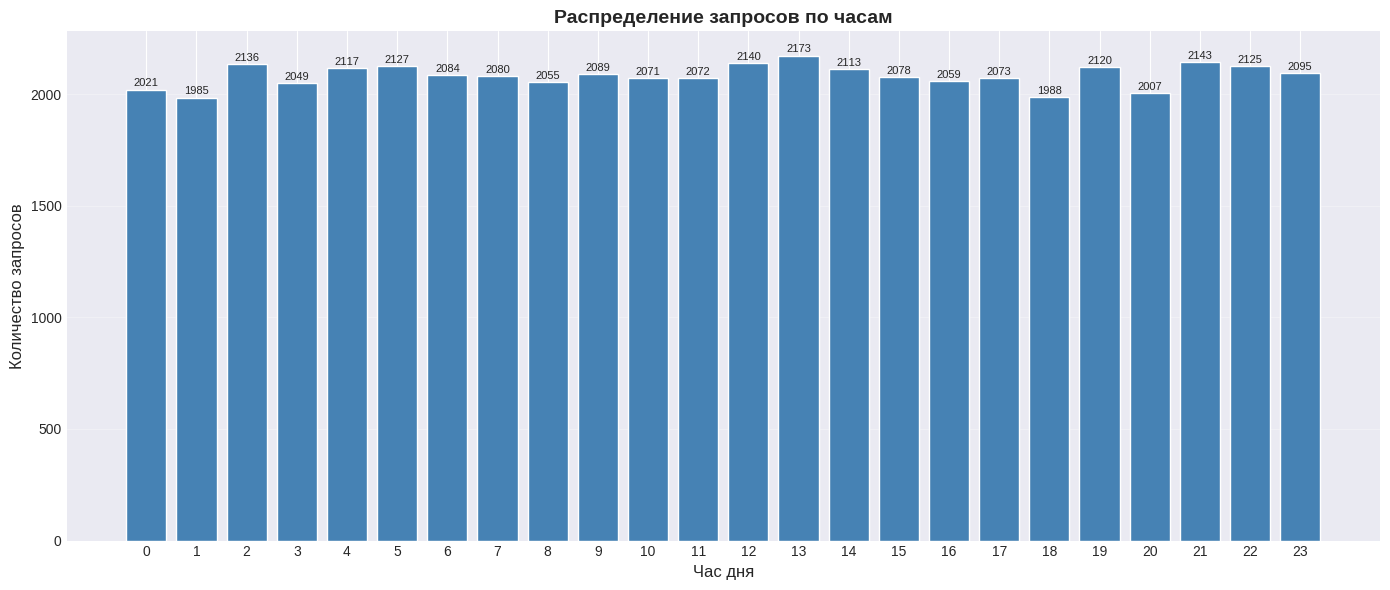

In [36]:
# ============================================================
# Ячейка 8.2: График активности по часам
# ============================================================
# Преобразуем данные Spark в Pandas DataFrame
hourly_pd = hourly_activity.toPandas()

plt.figure(figsize=(14, 6))
bars = plt.bar(hourly_pd['hour'], hourly_pd['requests'], color='steelblue', edgecolor='white')
plt.xlabel('Час дня', fontsize=12)
plt.ylabel('Количество запросов', fontsize=12)
plt.title('Распределение запросов по часам', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)

# Добавление значений над столбцами
for bar, val in zip(bars, hourly_pd['requests']):
    if val > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(val)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


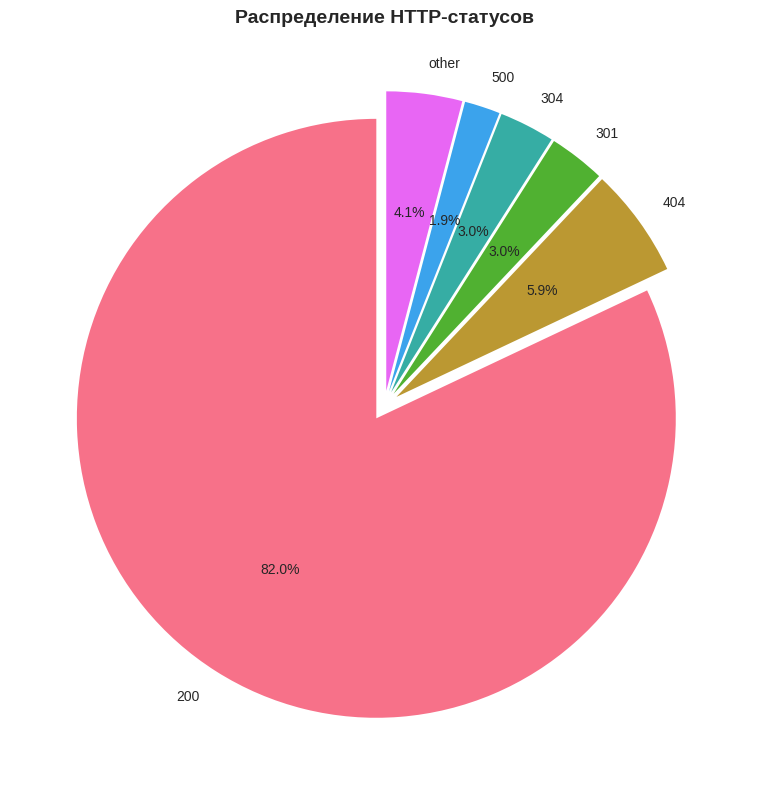

In [37]:
# ============================================================
# Ячейка 8.3: Круговая диаграмма распределения статусов (FIX)
# ============================================================
status_pd = status_distribution.toPandas()

# Группируем мелкие категории
top_status = status_pd.nlargest(5, 'count')
other_count = status_pd[~status_pd['status'].isin(top_status['status'])]['count'].sum()

if other_count > 0:
    top_status = pd.concat([
        top_status,
        pd.DataFrame({
            'status': ['other'],
            'count': [other_count],
            'percentage': [other_count / status_pd['count'].sum() * 100]
        })
    ])

colors = []
for s in top_status['status']:
    if s == 'other':
        colors.append('gray')
    elif int(s) < 300:
        colors.append('green')
    elif int(s) < 400:
        colors.append('orange')
    elif int(s) < 500:
        colors.append('red')
    else:
        colors.append('darkred')

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.pie(
    top_status['count'],
    labels=top_status['status'],
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05] * len(top_status)
)
plt.title('Распределение HTTP-статусов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



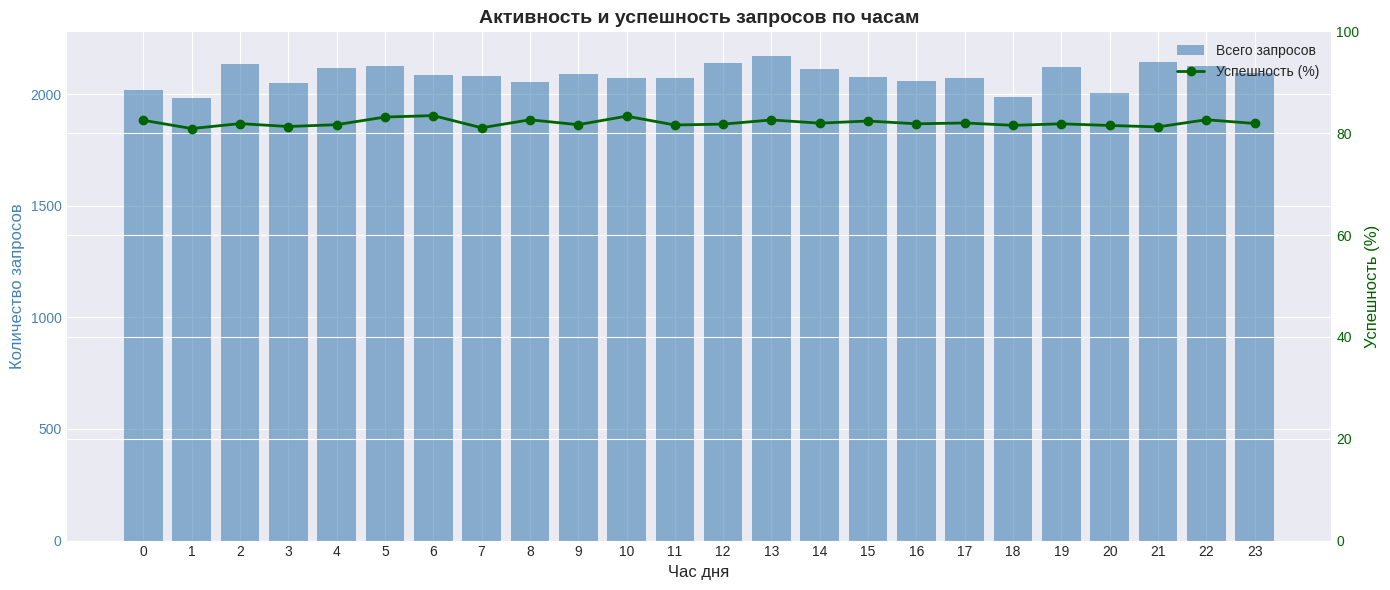

In [38]:
# ============================================================
# Ячейка 8.4: График успешности запросов по часам
# ============================================================
success_rate_pd = hourly_success_rate.toPandas()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Столбцы для количества запросов
ax1.bar(success_rate_pd['hour'], success_rate_pd['total'],
        color='steelblue', alpha=0.6, label='Всего запросов')
ax1.set_xlabel('Час дня', fontsize=12)
ax1.set_ylabel('Количество запросов', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Линия для процента успешных запросов
ax2 = ax1.twinx()
ax2.plot(success_rate_pd['hour'], success_rate_pd['success_rate'],
         color='darkgreen', marker='o', linewidth=2, markersize=6, label='Успешность (%)')
ax2.set_ylabel('Успешность (%)', fontsize=12, color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')
ax2.set_ylim(0, 100)

plt.title('Активность и успешность запросов по часам', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(axis='x', alpha=0.3)

# Легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()


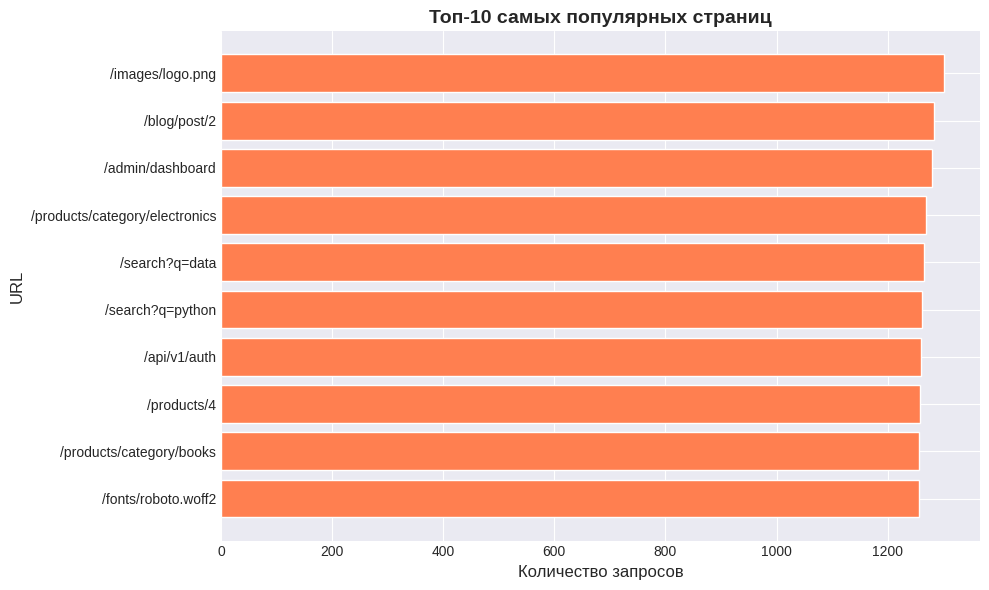

In [39]:
# ============================================================
# Ячейка 8.5: Топ-10 страниц (горизонтальная диаграмма)
# ============================================================
top_pd = top_endpoints.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(top_pd['endpoint'], top_pd['requests_count'], color='coral', edgecolor='white')
plt.xlabel('Количество запросов', fontsize=12)
plt.ylabel('URL', fontsize=12)
plt.title('Топ-10 самых популярных страниц', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



# Часть 9. Контрольные вопросы
Ответьте на следующие вопросы в отдельной Markdown-ячейке:

1.	Что такое RDD? В чем разница между трансформацией и действием в Spark? Приведите примеры из выполненной работы.

RDD (Resilient Distributed Dataset) — это фундаментальная абстракция Spark, представляющая собой распределенную коллекцию объектов, которая устойчива к сбоям и может обрабатываться параллельно. RDD хранится в памяти или на диске и разделена на партиции.

Трансформация — это операция, которая создает новый RDD из существующего. Трансформации выполняются лениво, то есть не запускают вычисления немедленно. Примеры: `map()`, `filter()`, `flatMap()`.

Действие — это операция, которая запускает выполнение всех накопленных трансформаций и возвращает результат драйверу или сохраняет его во внешнее хранилище. Примеры: `count()`, `take()`, `saveAsTextFile()`.

Трансформация: `logs_rdd.filter(lambda line: " 404 " in line)` — создает новый RDD с отфильтрованными строками, но ничего не вычисляет.

Действие: `errors_404.count()` — запускает вычисления и возвращает количество строк с ошибкой 404.

2.	Почему для парсинга логов мы использовали регулярные выражения, а не просто поиск подстроки?

Поиск по подстроке, например `" 404 "`, является ненадежным по нескольким причинам. Во-первых, подстрока "404" может встречаться в других местах лога, например в URL (`/page-404.html`), в теле запроса или в параметрах поиска, что приведет к ложным срабатываниям. Во-вторых, реальные строки с ошибкой 404 могут быть пропущены, если после кода статуса нет пробела (строка заканчивается) или используются другие разделители, такие как табуляция. В-третьих, поиск по подстроке не позволяет извлечь отдельные поля лога — он лишь проверяет наличие фрагмента. Регулярные выражения позволяют точно извлечь каждое поле из правильной позиции в строке, учитывая возможные вариации формата, и преобразовать их в структурированные данные для дальнейшего анализа.

3.	Какие преимущества дает использование DataFrame по сравнению с RDD?

Использование DataFrame предоставляет несколько важных преимуществ перед RDD. Во-первых, DataFrame имеет схему данных, что позволяет Spark оптимизировать выполнение запросов через Catalyst Optimizer. Во-вторых, DataFrame использует Tungsten execution engine для эффективной работы с памятью и двоичным представлением данных, что значительно повышает производительность. В-третьих, DataFrame поддерживает SQL-подобный синтаксис, который более понятен и требует меньше кода по сравнению с операциями на RDD. В-четвертых, DataFrame автоматически выбирает оптимальный план выполнения запроса. В-пятых, паркетные и другие колоночные форматы лучше интегрируются с DataFrame.

4.	Что такое ленивые вычисления (Lazy Evaluation) в Spark? Как это влияет на производительность?

Ленивые вычисления означают, что Spark не выполняет трансформации немедленно при их вызове, а только запоминает последовательность операций в виде графа вычислений (DAG). Фактическое выполнение происходит только при вызове действия, такого как `count()` или `collect()`.

Влияние на производительность положительное. Во-первых, Spark может оптимизировать порядок операций, например объединять несколько трансформаций в один проход по данным. Во-вторых, можно избежать ненужных промежуточных вычислений и сократить количество проходов по данным. В-третьих, Spark может выбирать наиболее эффективный план выполнения на основе анализа всего графа операций. В-четвертых, при сбоях не нужно пересчитывать все заново, только утерянные партиции.

5.	Для чего нужна регистрация временного представления (Temp View)?

Регистрация временного представления (Temp View) нужна для того, чтобы выполнять SQL-запросы к DataFrame с помощью метода `spark.sql()`. После вызова `createOrReplaceTempView()` DataFrame становится доступным как виртуальная таблица в SQL-движке Spark. Это дает возможность использовать знакомый синтаксис SQL для анализа данных, что особенно удобно для аналитиков и специалистов по данным, которые привыкли работать с реляционными базами данных.

6.	Какие выводы о поведении пользователей вы можете сделать на основе анализа активности по часам?

Равномерность нагрузки — количество запросов распределено относительно равномерно в течение суток (от ~1985 до ~2173 запросов в час). Нет ярко выраженных «часов пик» или «часов затишья». Это может указывать на то, что сервер обслуживает глобальную аудиторию из разных часовых поясов или что нагрузка создаётся автоматизированными системами (ботами, краулерами).

Небольшой рост активности наблюдается в часы с 12 до 14 (около 2140–2173 запросов) и с 21 до 22 (около 2143 запросов). Это может соответствовать обеденному перерыву и вечернему времени пользователей.

Ошибки 404 чаще всего возникают в 23 часа (142 ошибки), 13 часов (137) и 12 часов (135). Это может указывать на то, что в эти часы пользователи активнее ищут контент, который был удалён или перемещён.

Ошибки 500 наиболее часты в 11 часов (54 ошибки) и 13 часов (50 ошибок). Это может свидетельствовать о периодических проблемах на сервере в середине дня, возможно, из-за повышенной нагрузки или плановых операций.

7.	Какой формат хранения данных (Parquet) вы использовали для сохранения результатов? В чем его преимущества перед CSV?

Для сохранения результатов использовался формат Parquet — колоночный формат хранения данных, оптимизированный для больших данных.

Преимущество перед CSV:
1) Скорость: Чтение нужных данных происходит в разы быстрее, так как не требуется сканировать весь файл.
2) Объем: Размер файлов значительно меньше благодаря эффективному сжатию.
3) Совместимость: Повсеместно используется в экосистеме Apache Hadoop (Spark, Hive, Impala) и других системах.

8.	Проанализируйте распределение HTTP-статусов. Какие статусы встречаются чаще всего? Что это может означать с точки зрения качества работы веб-сервера?

200 OK — 82,02% (41 012 запросов) — сервер работает нормально.

404 Not Found — 5,93% (2 966 запросов) — значительное количество запросов к несуществующим страницам, что требует исправления битых ссылок.

301/304 — около 6% в сумме — нормальное поведение, связанное с редиректами и кэшированием.

400/403 — около 3% — клиентские ошибки.

500/503 — около 2,9% — ошибки сервера, требующие анализа кода и инфраструктуры.

Веб-сервер работает достаточно стабильно (82% успешных ответов), но требует серьёзной доработки: необходимо исправить причины внутренних ошибок сервера (500) и настроить обработку несуществующих страниц (404). После устранения этих проблем качество работы сервера можно будет оценить как отличное.

